In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print("=" * 90)
print("   HOLLAND BARRIER — STRUCTURAL LOAD CALCULATION")
print("   Storm Surge Barrier Gate (Sector Gate)")
print("   NEN-EN 1990 / WOWK / CC3 (β = 4.3)")
print("=" * 90)


   HOLLAND BARRIER — STRUCTURAL LOAD CALCULATION
   Storm Surge Barrier Gate (Sector Gate)
   NEN-EN 1990 / WOWK / CC3 (β = 4.3)


In [81]:
# ============================================================
#    Self-weight compared to Maeslantkering
# ============================================================

w_retaining_wall_maeslant = 6800 # ton
w_truss_arms_maeslant = 6000 # ton
w_total_maeslant = w_retaining_wall_maeslant + w_truss_arms_maeslant

a_approximator = 24.75 / 22 # approximation number calculated from the height difference between maeslant and Holland barrier to make an assumption
w_retaining_wall_holland = w_retaining_wall_maeslant * a_approximator

G_retaining_wall = w_retaining_wall_holland / (9.81 * 248) # kN/m

w_total_holland = w_total_maeslant * a_approximator

G_total = w_total_holland / (9.81 * 248) # kN/m

print(G_retaining_wall)
print(G_total)


3.144421426457532
5.918910920390648


In [82]:

# ============================================================
# 1. INPUT PARAMETERS
# ============================================================

# --- Physical constants ---
g = 9.81            # m/s²
rho_w = 1025.0      # kg/m³ (salt water)
rho_air = 1.25      # kg/m³
gamma_steel = 78.0  # kN/m³

# --- Hydraulic boundary conditions ---
h_sea = 6        # m above NAP (design water level, sea side)
h_river = 3.30      # m above NAP (water level river side at closure)
z_sill = -17.0      # m NAP (threshold / sill level)
delta_h_rev = 1.80  # m (reversed hydraulic head)

# Water depths above sill
d_sea = h_sea - z_sill
d_river = h_river - z_sill
delta_h = h_sea - h_river

# --- Wave parameters --- T = 100,000
H_s = 3.65          # m (significant wave height)
T_f = 12.85         # s (spectral wave period)
H_d = 2 * H_s     # design wave height (Rayleigh)


# --- Temperature ---
T_min = -15.0       # °C
T_max = 35.0        # °C
delta_T = T_max - T_min
alpha_steel = 1.2e-5    # 1/°C
E_steel = 210e3          # MPa


# --- Gate geometry ---
H_gate = 24.75       # m (gate height, sill to top)
B_gate = 360.0      # m total width
h_above_water = H_gate + z_sill - h_sea # m (gate height above design water level)
h_above_water_wind = H_gate + z_sill# m (worst case scenario for wind on gate)
A_wind = B_gate * h_above_water_wind   # m² (exposed area for wind)
A_current = B_gate * d_sea        # m² (submerged area during closure)




In [83]:
# ============================================================
# 2. WAVELENGTH (Dispersion Relation)
# ============================================================
print("\n" + "=" * 90)
print("2. WAVELENGTH — Dispersion Relation")
print("=" * 90)

d = d_sea  # governing water depth (sea side above sill)
L_deep = (g * T_f**2) / (2 * np.pi)  # deep water wavelength

# Iterative solution: L = L_deep * tanh(2*pi*d/L)
L = L_deep
for _ in range(100):
    L_new = L_deep * np.tanh(2 * np.pi * d / L)
    if abs(L_new - L) < 1e-6:
        break
    L = L_new
L = L_new

k = 2 * np.pi / L  # wave number

print(f"  Deep water wavelength L_0      = {L_deep:.2f} m")
print(f"  Water depth d                  = {d:.2f} m")
print(f"  Wavelength L (iterative)       = {L:.2f} m")
print(f"  Wave number k                  = {k:.4f} rad/m")
print(f"  d/L                            = {d/L:.3f}")
print(f"  Depth classification:          ", end="")
if d / L > 0.5:
    print("Deep water")
elif d / L > 0.05:
    print("Transitional water")
else:
    print("Shallow water")




2. WAVELENGTH — Dispersion Relation
  Deep water wavelength L_0      = 257.81 m
  Water depth d                  = 23.00 m
  Wavelength L (iterative)       = 174.91 m
  Wave number k                  = 0.0359 rad/m
  d/L                            = 0.131
  Depth classification:          Transitional water


In [84]:
print(f"Hs/L = {H_s/L:.2f} << 1")
print(f"Hs/d = {H_s/d_sea:.2f} << 1")

print("Linear wave theory is possible")

Hs/L = 0.02 << 1
Hs/d = 0.16 << 1
Linear wave theory is possible


In [85]:
# ============================================================
# 3. HYDROSTATIC LOADS
# ============================================================
print("\n" + "=" * 90)
print("3. HYDROSTATIC LOADS (per unit width)")
print("=" * 90)

# --- Seaward loading (positive head) ---
p_bottom_sea = rho_w * g * d_sea       # Pa
p_bottom_river = rho_w * g * d_river   # Pa

F_hydro_sea = 0.5 * rho_w * g * d_sea**2      # N/m
F_hydro_river = 0.5 * rho_w * g * d_river**2  # N/m
F_hydro_net = F_hydro_sea - F_hydro_river      # N/m

# --- Reversed hydraulic head ---
F_hydro_rev_exact = 0.5 * rho_w * g * ((d_river + delta_h_rev)**2 - d_river**2)

print(f"\n  --- Seaward Loading (Positive Head) ---")
print(f"  Water depth sea side  d_sea    = {d_sea:.2f} m")
print(f"  Water depth river side d_river = {d_river:.2f} m")
print(f"  Hydraulic head Δh              = {delta_h:.2f} m")
print(f"  Bottom pressure (sea)          = {p_bottom_sea/1000:.2f} kPa")
print(f"  Bottom pressure (river)        = {p_bottom_river/1000:.2f} kPa")
print(f"  F_hydro (sea side)             = {F_hydro_sea/1000:.2f} kN/m")
print(f"  F_hydro (river side)           = {F_hydro_river/1000:.2f} kN/m")
print(f"  F_hydro,net (seaward)          = {F_hydro_net/1000:.2f} kN/m")

print(f"\n  --- Reversed Hydraulic Head ---")
print(f"  Reversed head Δh_rev           = {delta_h_rev:.2f} m")
print(f"  F_hydro,rev                    = {F_hydro_rev_exact/1000:.2f} kN/m")




3. HYDROSTATIC LOADS (per unit width)

  --- Seaward Loading (Positive Head) ---
  Water depth sea side  d_sea    = 23.00 m
  Water depth river side d_river = 20.30 m
  Hydraulic head Δh              = 2.70 m
  Bottom pressure (sea)          = 231.27 kPa
  Bottom pressure (river)        = 204.12 kPa
  F_hydro (sea side)             = 2659.61 kN/m
  F_hydro (river side)           = 2071.83 kN/m
  F_hydro,net (seaward)          = 587.78 kN/m

  --- Reversed Hydraulic Head ---
  Reversed head Δh_rev           = 1.80 m
  F_hydro,rev                    = 383.71 kN/m


Wavelength L = 174.91 m
Wave number k = 0.0359 1/m
kh = 0.83



RESULTS
-------------------------------
Resultant force F = 1.654 MN/m
Moment about bed = 23.606 MNm/m
Centre of pressure = 14.270 m above bed
Centre of pressure = 8.730 m below SWL


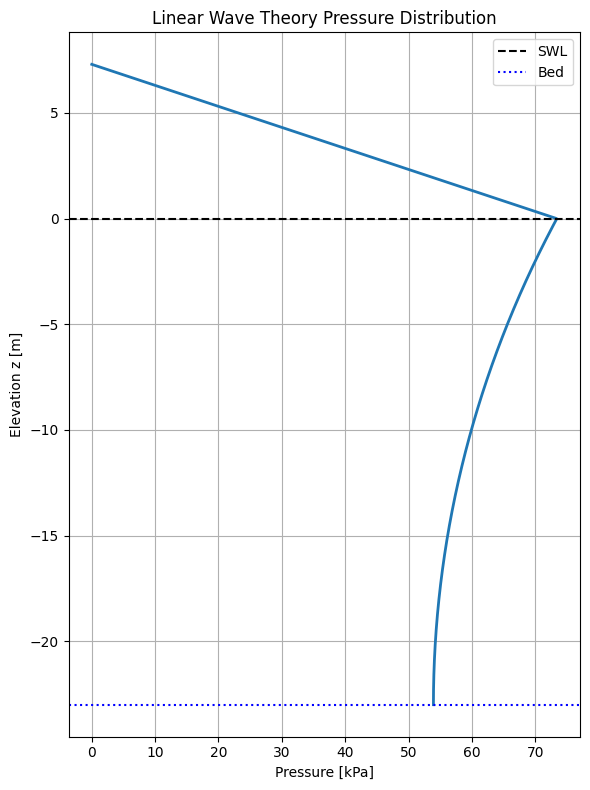

In [86]:

# ==========================================================
# INPUT
# ==========================================================

rho = 1025      # kg/m3
g = 9.81        # m/s2

# --- Wave parameters --- T = 100,000
H_s = 3.65          # m (significant wave height)
Hi = H_s *2
T = 12.85         # s (spectral wave period)
d = 23.0        # water depth [m]

# ==========================================================
# DISPERSION RELATION
# ==========================================================

def dispersion(L):
    return L - g * T**2 / (2*np.pi) * np.tanh(2*np.pi*d / L)

L0 = g * T**2 / (2*np.pi)          # deep water guess
L = fsolve(dispersion, L0)[0]

k = 2*np.pi / L

print(f"Wavelength L = {L:.2f} m")
print(f"Wave number k = {k:.4f} 1/m")
print(f"kh = {k*d:.2f}")

# ==========================================================
# PRESSURE DISTRIBUTION
# (Manual Hydraulic Structures Eq. 12.2)
# ==========================================================

z = np.linspace(-d, Hi, 2000)

p = np.zeros_like(z)

# below SWL
mask1 = (z >= -d) & (z <= 0)

p[mask1] = (
    rho * g * Hi *
    np.cosh(k * (d + z[mask1])) /
    np.cosh(k * d)
)

# above SWL
mask2 = (z > 0) & (z <= Hi)

p[mask2] = rho * g * Hi * (1 - z[mask2] / Hi)

# ==========================================================
# RESULTANT FORCE
# ==========================================================

F = np.trapezoid(p, z)      # N/m

# ==========================================================
# MOMENT ABOUT BED
# ==========================================================

M = np.trapezoid(p * (z + d), z)

z_cp = M / F           # centre of pressure above bed

# ==========================================================
# OUTPUT
# ==========================================================

print("\nRESULTS")
print("-------------------------------")
print(f"Resultant force F = {F/1e6:.3f} MN/m")
print(f"Moment about bed = {M/1e6:.3f} MNm/m")
print(f"Centre of pressure = {z_cp:.3f} m above bed")
print(f"Centre of pressure = {d-z_cp:.3f} m below SWL")

# ==========================================================
# PLOT
# ==========================================================

plt.figure(figsize=(6,8))

plt.plot(p/1000, z, linewidth=2)

plt.axhline(0, color='k', linestyle='--', label='SWL')
plt.axhline(-d, color='b', linestyle=':', label='Bed')

plt.xlabel('Pressure [kPa]')
plt.ylabel('Elevation z [m]')
plt.title('Linear Wave Theory Pressure Distribution')

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()


4. COMBINED HYDROSTATIC + WAVE PRESSURE DISTRIBUTION

  --- Wave load check from pressure distribution ---
  F_wave                         = 1654.23 kN/m
  M_wave about sill              = 23605.68 kNm/m
  z_cp,wave above sill           = 14.27 m
  z_cp,wave NAP                  = -2.73 m NAP
  z_cp,wave below sea SWL        = 8.73 m

  --- Combination 1: net hydrostatic pressure only ---
  F_hydro,net                    = 587.78 kN/m
  M_hydro,net about sill         = 6370.96 kNm/m
  z_cp,hydro above sill          = 10.84 m
  z_cp,hydro NAP                 = -6.16 m NAP
  z_cp,hydro below sea SWL       = 12.16 m

  --- Combination 2: net hydrostatic pressure + wave pressure ---
  F_hydro+wave                   = 2242.01 kN/m
  M_hydro+wave about sill        = 29976.65 kNm/m
  z_cp,hydro+wave above sill     = 13.37 m
  z_cp,hydro+wave NAP            = -3.63 m NAP
  z_cp,hydro+wave below sea SWL  = 9.63 m


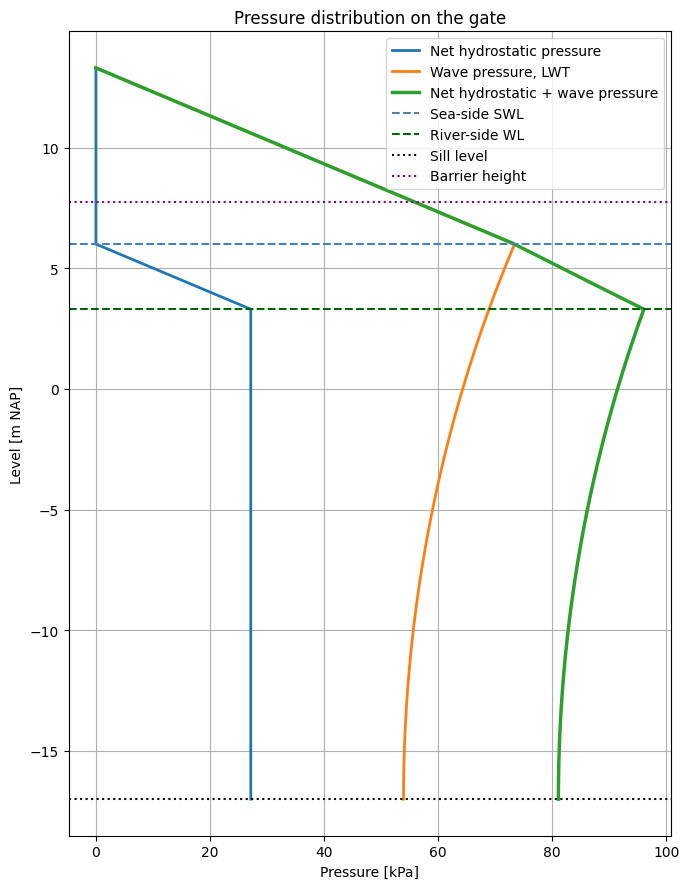

In [87]:
# ============================================================
# 4. COMBINED HYDROSTATIC + WAVE PRESSURE DISTRIBUTION
# ============================================================

print("\n" + "=" * 90)
print("4. COMBINED HYDROSTATIC + WAVE PRESSURE DISTRIBUTION")
print("=" * 90)

# ------------------------------------------------------------
# Check water density variable
# ------------------------------------------------------------
try:
    rho_w
except NameError:
    rho_w = rho

# ------------------------------------------------------------
# Coordinate system
# z_NAP is the vertical coordinate in m NAP
# z_sill is the bottom / sill level
# h_sea is the still water level at sea side
# Positive pressure acts from sea side to river side
# ------------------------------------------------------------

z_max = h_sea + Hi          # include wave crest above SWL
z_NAP = np.linspace(z_sill, z_max, 3000)

# Relative vertical coordinate with respect to sea-side SWL
# This is needed for the LWT pressure formula
z_rel = z_NAP - h_sea       # z = 0 at SWL, z = -d at sill

# ============================================================
# HYDROSTATIC PRESSURE DISTRIBUTIONS
# ============================================================

# Sea-side hydrostatic pressure
p_hydro_sea = np.where(
    z_NAP <= h_sea,
    rho_w * g * (h_sea - z_NAP),
    0.0
)

# River-side hydrostatic pressure
p_hydro_river = np.where(
    z_NAP <= h_river,
    rho_w * g * (h_river - z_NAP),
    0.0
)

# Net hydrostatic pressure, positive from sea to river
p_hydro_net = p_hydro_sea - p_hydro_river

# ============================================================
# WAVE PRESSURE DISTRIBUTION FROM LINEAR WAVE THEORY
# ============================================================

p_wave = np.zeros_like(z_NAP)

# Below sea-side still water level
mask_below_swl = (z_rel >= -d_sea) & (z_rel <= 0)

p_wave[mask_below_swl] = (
    rho_w * g * Hi *
    np.cosh(k * (d_sea + z_rel[mask_below_swl])) /
    np.cosh(k * d_sea)
)

# Above sea-side still water level up to the wave crest
mask_above_swl = (z_rel > 0) & (z_rel <= Hi)

p_wave[mask_above_swl] = (
    rho_w * g * Hi *
    (1 - z_rel[mask_above_swl] / Hi)
)

# ============================================================
# LOAD COMBINATIONS
# ============================================================

# Combination 1: hydrostatic load only
p_comb_hydro = p_hydro_net

# Combination 2: hydrostatic load + wave load
p_comb_hydro_wave = p_hydro_net + p_wave

# ============================================================
# FUNCTION TO CALCULATE RESULTANT FORCE AND POINT OF APPLICATION
# ============================================================

def resultant_and_application_height(p, z, z_ref):
    """
    Calculates resultant force and moment per metre width.

    Parameters
    ----------
    p : array
        Pressure distribution [Pa = N/m2]
    z : array
        Vertical coordinate [m NAP]
    z_ref : float
        Reference level for moment calculation [m NAP]

    Returns
    -------
    F : float
        Resultant force per metre width [N/m]
    M_ref : float
        Moment around reference level [Nm/m]
    z_cp_above_ref : float
        Centre of pressure above reference level [m]
    z_cp_NAP : float
        Centre of pressure level [m NAP]
    """

    F = np.trapezoid(p, z)
    M_ref = np.trapezoid(p * (z - z_ref), z)

    if abs(F) > 1e-9:
        z_cp_above_ref = M_ref / F
        z_cp_NAP = z_ref + z_cp_above_ref
    else:
        z_cp_above_ref = np.nan
        z_cp_NAP = np.nan

    return F, M_ref, z_cp_above_ref, z_cp_NAP


# ============================================================
# RESULTANTS
# ============================================================

F_hydro_comb, M_hydro_comb, zcp_hydro_above_sill, zcp_hydro_NAP = \
    resultant_and_application_height(p_comb_hydro, z_NAP, z_sill)

F_hw_comb, M_hw_comb, zcp_hw_above_sill, zcp_hw_NAP = \
    resultant_and_application_height(p_comb_hydro_wave, z_NAP, z_sill)

F_wave_check, M_wave_check, zcp_wave_above_sill, zcp_wave_NAP = \
    resultant_and_application_height(p_wave, z_NAP, z_sill)

# ============================================================
# OUTPUT
# ============================================================

print("\n  --- Wave load check from pressure distribution ---")
print(f"  F_wave                         = {F_wave_check/1000:.2f} kN/m")
print(f"  M_wave about sill              = {M_wave_check/1000:.2f} kNm/m")
print(f"  z_cp,wave above sill           = {zcp_wave_above_sill:.2f} m")
print(f"  z_cp,wave NAP                  = {zcp_wave_NAP:.2f} m NAP")
print(f"  z_cp,wave below sea SWL        = {h_sea - zcp_wave_NAP:.2f} m")

print("\n  --- Combination 1: net hydrostatic pressure only ---")
print(f"  F_hydro,net                    = {F_hydro_comb/1000:.2f} kN/m")
print(f"  M_hydro,net about sill         = {M_hydro_comb/1000:.2f} kNm/m")
print(f"  z_cp,hydro above sill          = {zcp_hydro_above_sill:.2f} m")
print(f"  z_cp,hydro NAP                 = {zcp_hydro_NAP:.2f} m NAP")
print(f"  z_cp,hydro below sea SWL       = {h_sea - zcp_hydro_NAP:.2f} m")

print("\n  --- Combination 2: net hydrostatic pressure + wave pressure ---")
print(f"  F_hydro+wave                   = {F_hw_comb/1000:.2f} kN/m")
print(f"  M_hydro+wave about sill        = {M_hw_comb/1000:.2f} kNm/m")
print(f"  z_cp,hydro+wave above sill     = {zcp_hw_above_sill:.2f} m")
print(f"  z_cp,hydro+wave NAP            = {zcp_hw_NAP:.2f} m NAP")
print(f"  z_cp,hydro+wave below sea SWL  = {h_sea - zcp_hw_NAP:.2f} m")


# ============================================================
# PLOT: HYDROSTATIC AND WAVE PRESSURE IN ONE GRAPH
# ============================================================

plt.figure(figsize=(7, 9))

plt.plot(
    p_hydro_net / 1000,
    z_NAP,
    linewidth=2,
    label="Net hydrostatic pressure"
)

plt.plot(
    p_wave / 1000,
    z_NAP,
    linewidth=2,
    label="Wave pressure, LWT"
)

plt.plot(
    p_comb_hydro_wave / 1000,
    z_NAP,
    linewidth=2.5,
    label="Net hydrostatic + wave pressure"
)

# Reference water levels
plt.axhline(h_sea, color="steelblue", linestyle="--", linewidth=1.5, label="Sea-side SWL")
plt.axhline(h_river, color="darkgreen", linestyle="--", linewidth=1.5, label="River-side WL")
plt.axhline(z_sill, color="black", linestyle=":", linewidth=1.5, label="Sill level")
plt.axhline((24.75-17), color="purple", linestyle=":", linewidth=1.5, label="Barrier height")


plt.xlabel("Pressure [kPa]")
plt.ylabel("Level [m NAP]")
plt.title("Pressure distribution on the gate")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [88]:
idx = np.argmax(p_wave)
pmax_wave = p_wave[idx]
z_pmax = z_NAP[idx]
print(f"pmax_wave = {pmax_wave/1000:.2f} kPa")
print(f"optreedt op z = {z_pmax:.2f} m NAP")
print(idx)

pmax_wave = 73.39 kPa
optreedt op z = 6.00 m NAP
2276


In [89]:
# with np.printoptions(threshold=np.inf):

#     print(p_comb_hydro_wave/1000)

np.savetxt("p_comb.csv", p_comb_hydro_wave/1000, delimiter=",")


GLOBAL GATE MODEL

q  = 2242.0 kN/m
W  = 551.534 MN

Support reactions
--------------------------
R1 = 367.689 MN
R2 = 183.845 MN

Critical values
--------------------------
Maximum positive moment  = 0.00 MNm
Location                 = 246.00 m
Maximum negative moment  = -9116.80 MNm
Location                 = 90.18 m
Maximum shear            = 202.19 MN


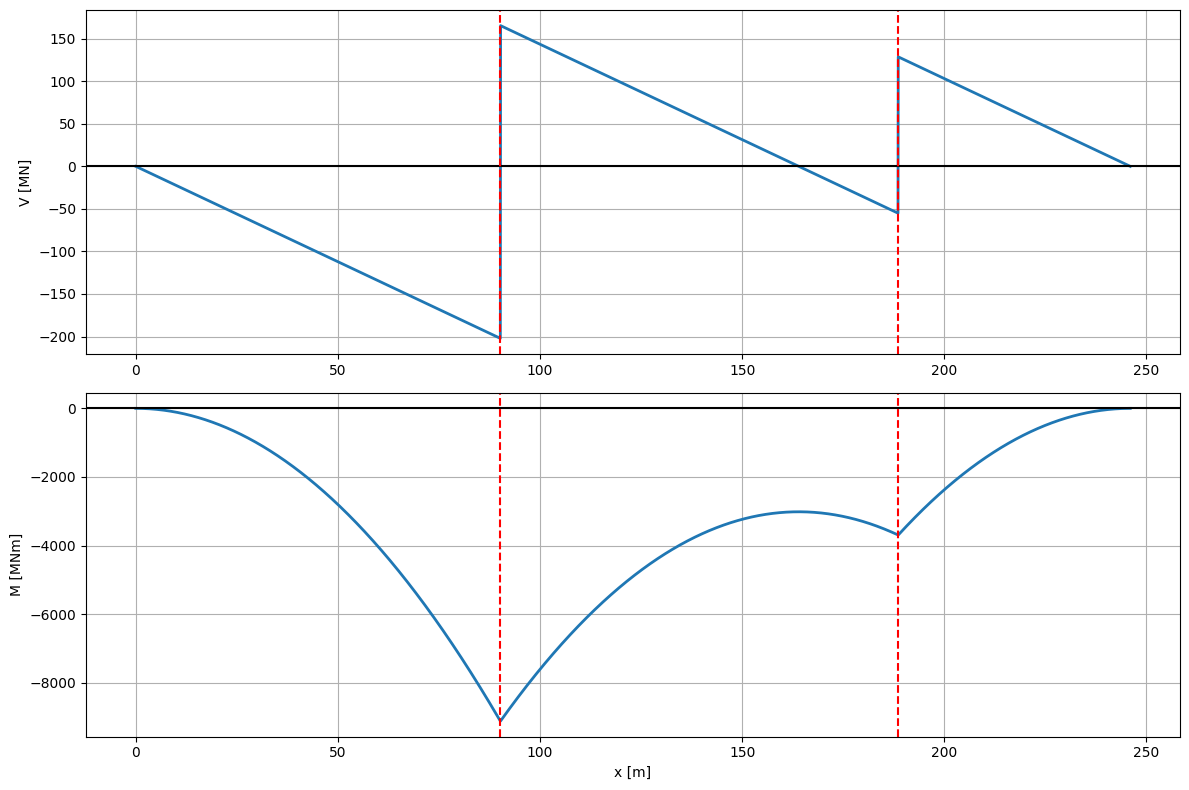

In [90]:
# ============================================================
# GLOBAL GATE MODEL
# Door modelled as horizontal beam
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# INPUT
# ------------------------------------------------------------

L = 246.0          # total gate width [m]

x1 = 90.2          # truss arm 1 [m]
x2 = 188.6         # truss arm 2 [m]

# from hydraulic calculation
q = F_hw_comb/1000      # kN/m

print("\n" + "="*80)
print("GLOBAL GATE MODEL")
print("="*80)

# ------------------------------------------------------------
# TOTAL LOAD
# ------------------------------------------------------------

W = q * L

x_load = L/2

# ------------------------------------------------------------
# SUPPORT REACTIONS
# ------------------------------------------------------------

R2 = W * (x_load - x1)/(x2 - x1)

R1 = W - R2

print(f"\nq  = {q:.1f} kN/m")
print(f"W  = {W/1000:.3f} MN")

print("\nSupport reactions")
print("--------------------------")
print(f"R1 = {R1/1000:.3f} MN")
print(f"R2 = {R2/1000:.3f} MN")

# ------------------------------------------------------------
# SHEAR AND MOMENT
# ------------------------------------------------------------

x = np.linspace(0, L, 4000)

V = np.zeros_like(x)
M = np.zeros_like(x)

for i, xi in enumerate(x):

    V[i] = -q * xi

    if xi >= x1:
        V[i] += R1

    if xi >= x2:
        V[i] += R2

    M[i] = -q * xi**2 / 2

    if xi >= x1:
        M[i] += R1 * (xi - x1)

    if xi >= x2:
        M[i] += R2 * (xi - x2)

# ------------------------------------------------------------
# CRITICAL LOCATIONS
# ------------------------------------------------------------

idx_max = np.argmax(M)
idx_min = np.argmin(M)

M_pos = M[idx_max]
x_pos = x[idx_max]

M_neg = M[idx_min]
x_neg = x[idx_min]

Vmax = np.max(np.abs(V))

print("\nCritical values")
print("--------------------------")

print(f"Maximum positive moment  = {M_pos/1000:.2f} MNm")
print(f"Location                 = {x_pos:.2f} m")

print(f"Maximum negative moment  = {M_neg/1000:.2f} MNm")
print(f"Location                 = {x_neg:.2f} m")

print(f"Maximum shear            = {Vmax/1000:.2f} MN")

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------

fig, ax = plt.subplots(2,1, figsize=(12,8))

# Shear

ax[0].plot(x, V/1000, lw=2)

ax[0].axhline(0,color='k')

ax[0].axvline(x1,color='r',ls='--')
ax[0].axvline(x2,color='r',ls='--')

ax[0].set_ylabel("V [MN]")

ax[0].grid(True)

# Moment

ax[1].plot(x, M/1000, lw=2)

ax[1].axhline(0,color='k')

ax[1].axvline(x1,color='r',ls='--')
ax[1].axvline(x2,color='r',ls='--')

ax[1].set_ylabel("M [MNm]")
ax[1].set_xlabel("x [m]")

ax[1].grid(True)

plt.tight_layout()
plt.show()

In [91]:
print(q)

2242.0076494942


In [92]:
"""
================================================================================
 VOLLEDIGE STERKTETOETS - GETRAPTE KOKERDOORSNEDE KERENDE WAND
--------------------------------------------------------------------------------
 Belasting horizontaal van links (waterdruk in stromingsrichting)
 => buiging in HORIZONTAAL vlak om de VERTICALE as
    - buighoogte  = breedte in stromingsrichting (b)
    - afschuiving = via boven/onderplaten (evenwijdig aan de last)

 Stappen:
   0  Invoer
   1  Classificatie (klasse 1/2/3/4, NEN-EN 1993-1-1 Tab. 5.2)
   2  Effectieve doorsnede - EXACTE effectieve-breedtemethode
      (randstroken per plaatveld + zwaartepuntverschuiving, NEN-EN 1993-1-5)
   3  Buigtoets
   4  Afschuiftoets
   4b Schuifplooi plaatveld (NEN-EN 1993-1-5 §5)
   5  M-V interactie
   7  Conclusie + benodigde dikte
 (stap 6 normaalkracht overgeslagen)

 Eenheden: SI  (N, m, Pa)
================================================================================
"""
import numpy as np
from scipy.optimize import brentq

# ================================================================= #
# STAP 0 - INVOER
# ================================================================= #
c = 1.125
# in stromingsrichting = breedte b (= buighoogte om verticale as)
# verticaal            = hoogte  h
b_top, h_top = 8.0*c, 14.5*c        # bovenkoker
b_bot, h_bot = 15.0*c, 7.5*c        # drijflichaam
H = h_top + h_bot                   # totale verticale hoogte

t_w   = 0.080                       # m   gekozen wanddikte
s_sch = 2.5#1.75                        # m   schotafstand h.o.h.

M_Ed = 9120.54e6                    # Nm  maatgevend moment (globaal model)
V_Ed = 202.19e6                     # N   maatgevende dwarskracht

f_y = 355e6; gamma_M0 = 1.0; E = 210e9
eps = np.sqrt(235e6/f_y)
sigma_Rd = f_y/gamma_M0
tau_Rd   = f_y/(np.sqrt(3)*gamma_M0)

print("="*76)
print(" STAP 0 - INVOER  (buiging om VERTICALE as, last van links)")
print("="*76)
print(f" Bovenkoker  : b={b_top:.3f} m (stroomrichting) x h={h_top:.3f} m")
print(f" Drijflichaam: b={b_bot:.3f} m (stroomrichting) x h={h_bot:.3f} m")
print(f" H(verticaal)={H:.3f} m | t_w={t_w*1000:.0f} mm | schot h.o.h.={s_sch:.2f} m")
print(f" M_Ed={M_Ed/1e6:.0f} MNm | V_Ed={V_Ed/1e6:.0f} MN")
print(f" S355: f_y={f_y/1e6:.0f} MPa | eps={eps:.4f}")

# ================================================================= #
# STAP 1 - CLASSIFICATIE (klasse 1/2/3/4)
#   interne drukdelen (volledige druk): grenzen 33/38/42 * eps
#   plaatbreedte begrensd door schotafstand
# ================================================================= #
print("\n"+"="*76); print(" STAP 1 - CLASSIFICATIE (NEN-EN 1993-1-1, Tab. 5.2)"); print("="*76)
lim1, lim2, lim3 = 33*eps, 38*eps, 42*eps

def classify(r):
    if   r <= lim1: return 1
    elif r <= lim2: return 2
    elif r <= lim3: return 3
    else:           return 4

panelen = {"bovenkoker drukplaat": min(b_top, s_sch),
           "bovenkoker lijf":      min(h_top, s_sch),
           "drijfl. drukplaat":    min(b_bot, s_sch),
           "drijfl. lijf":         min(h_bot, s_sch)}

print(f" grenzen: kl.1<={lim1:.1f} | kl.2<={lim2:.1f} | kl.3<={lim3:.1f} | kl.4>{lim3:.1f}\n")
print(f" {'paneel':22s} | {'c/t':>6} | klasse")
print("-"*44)
klassen = []
for naam, bp in panelen.items():
    r = bp/t_w; kl = classify(r); klassen.append(kl)
    print(f" {naam:22s} | {r:6.1f} | {kl}")
kl_gov = max(klassen)
print(f"\n Maatgevende doorsnedeklasse = klasse {kl_gov}")
if kl_gov <= 2:
    print(" -> plastische weerstand toegestaan (hier conservatief elastisch gerekend)")
elif kl_gov == 3:
    print(" -> elastische weerstand (Mel = Wel*fy)")
else:
    print(" -> effectieve doorsnede vereist (plooireductie)")

# ================================================================= #
# STAP 2 - EFFECTIEVE DOORSNEDE (EXACTE METHODE)
#   Vezelmodel om verticale as. Effectieve breedte per plaatveld:
#     - drukflens (psi=+1, ksig=4.0): stroken 0.5*b_eff aan velduiteinden
#     - stegen    (psi=-1, ksig=23.9): stroken 0.4/0.6*b_eff in drukzone
#   Zwaartepuntverschiuving + Iz + Wz exact. Genormaliseerd op Wz_full bij rho=1.
# ================================================================= #
print("\n"+"="*76); print(" STAP 2 - EFFECTIEVE DOORSNEDE (exacte effectieve-breedtemethode)"); print("="*76)

def rho_uniform(bbar, t):    # intern deel, psi=+1
    lam = (bbar/t)/(28.4*eps*np.sqrt(4.0))
    return (1.0, lam) if lam <= 0.673 else (min((lam-0.055*(3+1))/lam**2, 1.0), lam)

def rho_bending(bbar, t):    # intern deel, psi=-1
    lam = (bbar/t)/(28.4*eps*np.sqrt(23.9))
    return (1.0, lam) if lam <= 0.673 else (min((lam-0.055*(3-1))/lam**2, 1.0), lam)

def cell_fibers(b, h, t, s_sch, n=1200):
    """Vezels (y, area) voor 1 holle koker; effectieve delen only."""
    ys, ar = [], []
    # comp-flens @ y=-b/2, verdeeld in velden van s_sch over hoogte h
    rho_f, _ = rho_uniform(min(s_sch, h), t)
    z = np.linspace(0, h, n); dz = h/n; A_el = t*dz
    w = s_sch
    for zi in z:
        pos = zi % w
        wl  = min(w, h-(zi-pos))          # laatste veld eventueel korter
        e   = 0.5*rho_f*wl
        if (pos <= e) or (pos >= wl-e):
            ys.append(-b/2); ar.append(A_el)
    # tens-flens @ y=+b/2 volledig effectief
    for zi in z:
        ys.append(+b/2); ar.append(A_el)
    # stegen (boven+onder), psi=-1
    rho_w, _ = rho_bending(min(b, s_sch), t)
    beff_w = rho_w*(b/2.0)
    be1, be2 = 0.4*beff_w, 0.6*beff_w
    yv = np.linspace(-b/2, b/2, n); dy = b/n; A_elw = t*dy
    for yi in yv:
        eff = True
        if yi < 0:
            eff = ((yi-(-b/2)) <= be1) or ((0-yi) <= be2)
        if eff:
            ys.append(yi); ar.append(A_elw)   # bovensteg
            ys.append(yi); ar.append(A_elw)   # ondersteg
    return np.array(ys), np.array(ar), rho_f, rho_w

def props_full(t):
    Iz = (h_top*b_top**3-(h_top-2*t)*(b_top-2*t)**3)/12 \
       + (h_bot*b_bot**3-(h_bot-2*t)*(b_bot-2*t)**3)/12
    A  = (b_top*h_top-(b_top-2*t)*(h_top-2*t)) + (b_bot*h_bot-(b_bot-2*t)*(h_bot-2*t))
    return A, Iz, Iz/(max(b_top, b_bot)/2)

def props_exact(t, s_sch):
    y1,a1,rf1,rw1 = cell_fibers(b_top,h_top,t,s_sch)
    y2,a2,rf2,rw2 = cell_fibers(b_bot,h_bot,t,s_sch)
    y = np.concatenate([y1,y2]); a = np.concatenate([a1,a2])
    A = a.sum(); yc = (a*y).sum()/A
    Iz = (a*(y-yc)**2).sum()
    y_ext = max(abs(y.max()-yc), abs(y.min()-yc))
    Wz = Iz/y_ext
    # discretisatie-normalisatie: schaal zodat rho=1 exact Wz_full geeft
    _,_,Wz_full = props_full(t)
    yr1,ar1,_,_ = cell_fibers(b_top,h_top,t,1e-3)   # zeer kleine schotafstand -> rho=1
    yr2,ar2,_,_ = cell_fibers(b_bot,h_bot,t,1e-3)
    yr=np.concatenate([yr1,yr2]); arr=np.concatenate([ar1,ar2])
    ycr=(arr*yr).sum()/arr.sum()
    Wz_fiber_full=(arr*(yr-ycr)**2).sum()/max(abs(yr.max()-ycr),abs(yr.min()-ycr))
    k_norm = Wz_full/Wz_fiber_full
    return A, Iz, Wz*k_norm, yc, y_ext, min(rf1,rf2), min(rw1,rw2)

Af, Izf, Wzf = props_full(t_w)
A, Iz, Wz, yc, y_ext, rho_f, rho_w = props_exact(t_w, s_sch)
bp_gov = min(max(h_top, h_bot), s_sch)
_, lam_p = rho_uniform(bp_gov, t_w)
print(f" Volledige doorsnede (ref): Wz_full={Wzf:.2f} m^3")
print(f" Maatgevend paneel={bp_gov:.2f} m -> lambda_p={lam_p:.3f}")
print(f" rho_flens={rho_f:.3f} | rho_steg={rho_w:.3f}")
print(" -> volledige doorsnede effectief" if min(rho_f,rho_w)>=0.999
      else " -> plooireductie toegepast (effectieve breedte)")
print(f" A={A:.3f} m^2 | Iz_eff={Iz:.1f} m^4 | Wz_eff={Wz:.2f} m^3")
print(f" zwaartepuntverschuiving yc={yc:.3f} m | y_ext={y_ext:.3f} m")

# ================================================================= #
# STAP 3 - BUIGTOETS
# ================================================================= #
print("\n"+"="*76); print(" STAP 3 - BUIGTOETS (om verticale as)"); print("="*76)
Mc_Rd  = Wz*f_y/gamma_M0
sigma_b = M_Ed/Wz
UC_M   = M_Ed/Mc_Rd
print(f" Mc_Rd={Mc_Rd/1e6:.0f} MNm | sigma_b={sigma_b/1e6:.1f} MPa | UC_M={UC_M:.3f}"
      f"  {'OK' if UC_M<=1 else 'FAIL'}")

# ================================================================= #
# STAP 4 - AFSCHUIFTOETS (horizontale platen evenwijdig aan de last)
# ================================================================= #
print("\n"+"="*76); print(" STAP 4 - AFSCHUIFTOETS"); print("="*76)
A_v  = 2*b_top*t_w + 2*b_bot*t_w
V_Rd = A_v*f_y/(np.sqrt(3)*gamma_M0)
tau  = V_Ed/A_v
UC_V = V_Ed/V_Rd
print(f" A_v=2*(b_top+b_bot)*t_w={A_v:.3f} m^2")
print(f" V_Rd={V_Rd/1e6:.0f} MN | tau={tau/1e6:.1f} MPa | UC_V={UC_V:.3f}"
      f"  {'OK' if UC_V<=1 else 'FAIL'}")

# ================================================================= #
# STAP 4b - SCHUIFPLOOI PLAATVELD (NEN-EN 1993-1-5 §5)
# ================================================================= #
print("\n"+"="*76); print(" STAP 4b - SCHUIFPLOOI PLAATVELD"); print("="*76)
eta = 1.2
hw  = s_sch                     # plaatveld tussen schotten
grens = 72*eps/eta
slank = hw/t_w
print(f" plaatveld hw/t_w={slank:.1f}  (schuifplooi als > 72*eps/eta={grens:.1f})")
if slank > grens:
    lam_w = hw/(37.4*t_w*eps*np.sqrt(5.34))
    chi_w = min(0.83/lam_w, 1.0) if lam_w >= 0.83 else 1.0
    Vb_Rd = chi_w*f_y*hw*t_w/(np.sqrt(3)*gamma_M0)
    print(f"  lambda_w={lam_w:.3f} -> chi_w={chi_w:.3f} (Vb_Rd per veld={Vb_Rd/1e6:.0f} MN)")
else:
    print("  geen schuifplooi (plaatveld voldoende gedrongen door schotten) -> OK")

# ================================================================= #
# STAP 5 - M-V INTERACTIE
# ================================================================= #
print("\n"+"="*76); print(" STAP 5 - INTERACTIE MOMENT + DWARSKRACHT"); print("="*76)
if V_Ed <= 0.5*V_Rd:
    print(f" V_Ed={V_Ed/1e6:.0f} MN <= 0.5*V_Rd={0.5*V_Rd/1e6:.0f} MN -> GEEN interactie")
    UC_int = UC_M
else:
    rho_v  = (2*V_Ed/V_Rd-1)**2
    UC_int = UC_M/(1-rho_v)
    print(f" V_Ed>0.5*V_Rd -> rho_v={rho_v:.3f}, UC_int={UC_int:.3f}")

# ================================================================= #
# STAP 7 - CONCLUSIE + BENODIGDE DIKTE
# ================================================================= #
print("\n"+"="*76); print(" STAP 7 - CONCLUSIE (UC-overzicht)"); print("="*76)
print(f" {'Buiging':26s} UC_M   = {UC_M:.3f}  {'OK' if UC_M<=1 else 'FAIL'}")
print(f" {'Afschuiving':26s} UC_V   = {UC_V:.3f}  {'OK' if UC_V<=1 else 'FAIL'}")
print(f" {'Interactie (maatgevend)':26s} UC_int = {UC_int:.3f}  {'OK' if UC_int<=1 else 'FAIL'}")
print("\n RESULTAAT:", "PASS" if max(UC_M,UC_V,UC_int)<=1 else "FAIL")

t_req = brentq(lambda t: (M_Ed/props_exact(t, s_sch)[2])/f_y - 1.0, 0.02, 0.5)
print(f"\n Benodigde dikte (buiging maatgevend, UC=1.0): t_req = {t_req*1000:.1f} mm")



 STAP 0 - INVOER  (buiging om VERTICALE as, last van links)
 Bovenkoker  : b=9.000 m (stroomrichting) x h=16.312 m
 Drijflichaam: b=16.875 m (stroomrichting) x h=8.438 m
 H(verticaal)=24.750 m | t_w=80 mm | schot h.o.h.=2.50 m
 M_Ed=9121 MNm | V_Ed=202 MN
 S355: f_y=355 MPa | eps=0.8136

 STAP 1 - CLASSIFICATIE (NEN-EN 1993-1-1, Tab. 5.2)
 grenzen: kl.1<=26.8 | kl.2<=30.9 | kl.3<=34.2 | kl.4>34.2

 paneel                 |    c/t | klasse
--------------------------------------------
 bovenkoker drukplaat   |   31.2 | 3
 bovenkoker lijf        |   31.2 | 3
 drijfl. drukplaat      |   31.2 | 3
 drijfl. lijf           |   31.2 | 3

 Maatgevende doorsnedeklasse = klasse 3
 -> elastische weerstand (Mel = Wel*fy)

 STAP 2 - EFFECTIEVE DOORSNEDE (exacte effectieve-breedtemethode)
 Volledige doorsnede (ref): Wz_full=25.91 m^3
 Maatgevend paneel=2.50 m -> lambda_p=0.676
 rho_flens=0.998 | rho_steg=1.000
 -> plooireductie toegepast (effectieve breedte)
 A=8.095 m^2 | Iz_eff=222.7 m^4 | Wz_eff=25

In [93]:

# ============================================================
# DIMENSIONERING skin plate - intercostals - girders (ULS)
# Piekdruk ingelezen uit p_comb.csv (load combination A)
# ============================================================


p_comb = F_hw_comb

# piekdruk = maximale (absolute) waarde over de hoogte
# p_Ed = np.max(np.abs(p_comb))                       # [Pa]  maatgevende druk
p_Ed = p_comb.max()
# print(f"Ingelezen drukverdeling: {len(p_comb)} punten")
print(f"Piekdruk  p_Ed = {p_Ed/1e3:.1f} kPa")
print(f"(gemiddelde druk = {np.mean(np.abs(p_comb))/1e3:.1f} kPa, "
      f"factor {p_Ed/np.mean(np.abs(p_comb)):.2f}x hoger)\n")

# --- materiaal S355 ---
f_y, gM0 = 355e6, 1.0
sig_Rd = f_y/gM0
eps = np.sqrt(235e6/f_y)

# ============================================================
# 1) SKIN PLATE - dikte gegeven intercostal-spacing
# ============================================================
def skin_plate_thickness(p, b, UC=1.0):
    return np.sqrt(p*b**2 / (2*UC*sig_Rd))

a_int = 0.68
t_p = np.ceil(skin_plate_thickness(p_Ed, a_int)*1000)/1000
lam_p = (a_int/t_p)/(28.4*eps*np.sqrt(4.0))
print("SKIN PLATE")
print(f"  intercostal-spacing a_int = {a_int:.2f} m")
print(f"  benodigde plaatdikte t_p  = {t_p*1000:.1f} mm")
print(f"  plaatslankheid lambda_p   = {lam_p:.3f}  "
      f"({'geen plooi' if lam_p<=0.673 else 'plooireductie'})\n")

# ============================================================
# 2) INTERCOSTALS - profiel gegeven girder-spacing
# ============================================================
def intercostal_sizing(p, a_int, L_int, UC=1.0):
    q_int = p * a_int
    M_int = q_int * L_int**2 / 12.0
    W_req = M_int / (UC*sig_Rd)
    V_int = q_int * L_int / 2.0
    return q_int, M_int, W_req, V_int

a_gird = 2.5
q_int, M_int, W_req_int, V_int = intercostal_sizing(p_Ed, a_int, a_gird)
t_w_int = 0.016
h_int = np.ceil(np.sqrt(6*W_req_int/t_w_int)*1000)/1000
A_v = h_int*t_w_int
V_Rd = A_v*f_y/(np.sqrt(3)*gM0)
print("INTERCOSTALS")
print(f"  girder-spacing L_int = {a_gird:.2f} m")
print(f"  lijnlast q_int       = {q_int/1e3:.1f} kN/m")
print(f"  moment M_int         = {M_int/1e3:.1f} kNm")
print

Piekdruk  p_Ed = 2242.0 kPa
(gemiddelde druk = 2242.0 kPa, factor 1.00x hoger)

SKIN PLATE
  intercostal-spacing a_int = 0.68 m
  benodigde plaatdikte t_p  = 39.0 mm
  plaatslankheid lambda_p   = 0.377  (geen plooi)

INTERCOSTALS
  girder-spacing L_int = 2.50 m
  lijnlast q_int       = 1524.6 kN/m
  moment M_int         = 794.0 kNm


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [94]:
# # ============================================================
# # 4. WAVE LOADS — Sainflou Method
# # ============================================================
# print("\n" + "=" * 90)
# print("4. WAVE LOADS — Sainflou Method (per unit width)")
# print("=" * 90)

# H_i = H_d  # incoming wave height for Sainflou
# d_ = d

# # Mean water level rise at the wall
# h_0 = 0.5 * k * H_i**2 * (np.cosh(k * d) / np.sinh(k * d))

# # Maximum pressure at mean water level
# p_1 = rho_w * g * (H_i + h_0)  # Pa

# # Maximum pressure at the bed
# p_0 = rho_w * g * H_i / np.cosh(k * d_)  # Pa

# # Height of pressure diagram
# h_pressure = d_ + h_0 + H_i

# # Total wave force per unit width
# F_wave_sainflou = 0.5 * p_1 * (h_0 + H_i) + p_0 * d_ + 0.5 * (p_1 -p_0) * d_  # N/m

# print(f"  Design wave height H_d         = {H_d:.2f} m")
# print(f"  Wavelength L                   = {L:.2f} m")
# print(f"  Wave number k                  = {k:.4f} rad/m")
# print(f"  Water depth d                  = {d:.2f} m")
# print(f"  cosh(kd)                       = {np.cosh(k*d):.4f}")
# print(f"  tanh(kd)                       = {np.tanh(k*d):.4f}")
# print(f"")
# print(f"  Mean water level rise h_0      = {h_0:.3f} m")
# print(f"  Pressure at MWL p_1            = {p_1/1000:.2f} kPa")
# print(f"  Pressure at bed p_0            = {p_0/1000:.2f} kPa")
# print(f"  Height of pressure diagram     = {h_pressure:.2f} m")
# print(f"  F_wave (Sainflou, per m width) = {F_wave_sainflou/1000:.2f} kN/m")
# print(f"  F_tot (Sainflou) = {F_wave_sainflou * 360 / 10**6:.2f} MN")



In [95]:
# # ============================================================
# # 4.b. WAVE LOADS — GODA
# # ============================================================

# print("\n" + "=" * 90)
# print("3. GODA METHOD — Wave pressure on caisson / gate on rockfill sill")
# print("=" * 90)

# # --- Extra Goda-specifieke parameters ---
# beta      = 0.0        # rad, hoek van invallende golf (0 = loodrecht)
# z_bed     = -17.0      # m NAP, bodemniveau vóór de drempel (drempelblokken 3.2 m hoog -> bed ~ -17 m)
# B_sill    = 5.6        # m, breedte van de drempel --> nog te bepalen
# lambda_1  = 1.0        # vormfactor (verticale wand, niet-brekende golf)
# lambda_2  = 1.0
# lambda_3  = 1.0

# # --- Afgeleide diepten ---
# h        = h_sea - z_bed       # waterdiepte vóór de drempel
# d_goda   = d_sea               # waterdiepte boven top drempel
# h_prime  = d_sea               # waterdiepte ter plaatse van funderingsvlak wand (wand op drempel)
# h_b      = h                   # waterdiepte op 5·H_D vóór de wand (≈ h)
# H_D      = H_d                 # ontwerpgolfhoogte
# L_D      = L                   # ontwerpgolflengte (uit dispersierelatie)
# h_c      = h_above_water       # kruinhoogte wand boven SWL

# # --- η* : verheffing boven SWL waar p = 0 ---
# eta_star = 0.75 * (1 + np.cos(beta)) * lambda_1 * H_D

# # --- α1 : dieptefactor ---
# alpha_1 = 0.6 + 0.5 * ((4*np.pi*h/L_D) / np.sinh(4*np.pi*h/L_D))**2

# # --- α2 : breker- / drempelfactor ---
# alpha_2 = min( ((1 - (d_goda / h_b)) * (H_D/d_goda)**2) /3 , 2*d_goda/H_D )

# # --- α3 : reductie langs de diepte ---
# alpha_3 = 1 - (h_prime/h) * (1 - 1/np.cosh(2*np.pi*h/L_D))

# # --- α4 : factor voor pressure-cut-off bij kruin ---
# h_c_star = min(eta_star, h_c)
# alpha_4    = 1 - h_c_star/eta_star if eta_star > 0 else 0.0

# # --- Goda druk-extrema (Pa) ---
# p1 = 0.5*(1 + np.cos(beta)) * (lambda_1*alpha_1 + lambda_2*alpha_2*np.cos(beta)**2) * rho_w*g*H_D
# # p2 = p1 / np.cosh(2*np.pi*h/L_D)
# p3 = alpha_3 * p1
# p4 = alpha_4 * p1
# p_u = 0.5*(1 + np.cos(beta)) * lambda_3 * alpha_1 * alpha_3 * rho_w*g*H_D

# # Conversie naar kN/m²
# p1_k, p3_k, p4_k, pu_k = (p/1000 for p in (p1, p3, p4, p_u))

# # --- Horizontale resulterende kracht per meter wand ---
# F_above_water = 0.5 * p1 * eta_star          # boven SWL 
# F_above_sill = 0.5 * p4 * (eta_star - h_c)
# F_below = 0.5 * (p1 - p3) * h_prime + p3 * h_prime           # onder SWL (trapezium p1 -> p3)
# F_h     = F_above_water + F_below                     # N/m

# # --- Uplift onder fundering (driehoek: p_u aan voorzijde, 0 aan achterzijde) ---
# F_u = 0.5 * p_u * B_sill                        # N/m

# # # --- Aangrijppunten (t.o.v. SWL) ---
# # # Bovenste deel: zwaartepunt driehoek/trapezium boven SWL
# # z_above = h_c_star * (p1 + 2*p4) / (3*(p1 + p4)) if (p1 + p4) > 0 else 0.0
# # # Onderste deel: zwaartepunt trapezium onder SWL (t.o.v. SWL, naar beneden positief)
# # z_below = -h_prime * (2*p3 + p1) / (3*(p3 + p1))
# # # Totaal aangrijppunt horizontale kracht t.o.v. SWL
# # z_Fh = (F_above_water*z_above + F_below*z_below) / F_h if F_h > 0 else 0.0
# # # Moment om basis van de wand (z = -h')
# # M_h = F_above_water*(h_c_star + h_prime - (h_c_star - z_above)) \
# #       + F_below*(h_prime + z_below)             # N·m/m

# # --- Resultaten ---
# goda_results = {
#     "Parameter": ["h (depth in front of sill)", "d (depth above sill)", "h' (depth at wall base)",
#                   "h_b (depth at 5·H_D)", "H_D", "L_D",
#                   "η*", "α1", "α2", "α3", "α4",
#                   "p1 (SWL)", "p3 (-h')", "p4 (top)", "p_u (uplift)",
#                   "F_h (horizontal)", "F_u (uplift)"],      #,"z_Fh (t.o.v. SWL)", "M_h (om basis wand)"
#     "Value": [f"{h:.2f}", f"{d_goda:.2f}", f"{h_prime:.2f}",
#               f"{h_b:.2f}", f"{H_D:.2f}", f"{L_D:.2f}",
#               f"{eta_star:.2f}", f"{alpha_1:.3f}", f"{alpha_2:.3f}",
#               f"{alpha_3:.3f}", f"{alpha_4:.3f}",
#               f"{p1_k:.2f}", f"{p3_k:.2f}", f"{p4_k:.2f}", f"{pu_k:.2f}",
#               f"{F_h/1000:.1f}", f"{F_u/1000:.1f}"], #, f"{z_Fh:.2f}", f"{M_h/1000:.1f}"
#     "Unit": ["m","m","m","m","m","m",
#              "m","—","—","—","—",
#              "kN/m²","kN/m²","kN/m²","kN/m²",
#              "kN/m","kN/m"]   #,"m","kNm/m"
# }
# print(pd.DataFrame(goda_results).to_string(index=False))

In [96]:
# print(f"{(F_h *360) / 10**6:.2f} MN") # MN totale water kracht

In [97]:
# # ============================================================
# # 5. WIND LOAD
# # ============================================================
# print("\n" + "=" * 90)
# print("5. WIND LOAD")
# print("=" * 90)

# qp = 0.5 * rho_air * u_wind**2
# F_wind_total = 0.5 * rho_air * u_wind**2 * C_D_wind * A_wind  # N
# F_wind_per_m = F_wind_total / B_gate  # N/m
# p_wind = 0.5 * rho_air * u_wind**2 * C_D_wind  # Pa

# print(f"  peak velociy pressure qp       = {qp/1000:.1f} kPa")
# print(f"  Wind velocity u_wind           = {u_wind:.1f} m/s")
# print(f"  Net force coefficient c_f      = {C_D_wind:.1f}")
# print(f"  Exposed area A_wind            = {A_wind:.0f} m²")
# print(f"  Wind pressure                  = {p_wind/1000:.2f} kPa")
# print(f"  F_wind (total on gate)         = {F_wind_total/1000:.2f} kN")
# print(f"  F_wind (per m gate width)      = {F_wind_per_m/1000:.2f} kN/m")



In [98]:
# # ============================================================
# # 6. CURRENT / DRAG LOAD
# # ============================================================
# print("\n" + "=" * 90)
# print("6. CURRENT / DRAG LOAD (during closure)")
# print("=" * 90)

# F_current_total = 0.5 * rho_w * u_current**2 * C_D_current * A_current  # N
# F_current_per_m = F_current_total / B_gate  # N/m


# print(f"  Current velocity u_current     = {u_current:.1f} m/s")
# print(f"  Drag coefficient C_D           = {C_D_current:.1f}")
# print(f"  Submerged area A_current       = {A_current:.0f} m²")
# print(f"  F_current (total)              = {F_current_total/1000:.2f} kN")
# print(f"  F_current (per m gate width)   = {F_current_per_m/1000:.2f} kN/m")

In [99]:
# # ============================================================
# # 7. ICE LOAD
# # ============================================================
# print("\n" + "=" * 90)
# print("8. ICE LOAD")
# print("=" * 90)


# print(f"  Ice load (characteristic)      = {F_ice_char:.0f} kN/m")
# print(f"  Gate width                     = {B_gate:.0f} m")
# print(f"  F_ice (total on gate)          = {F_ice_total:.0f} kN")